# Creating a SA Heart Web App


In [ ]:
!pip install streamlit pyngrok

In [ ]:
!ngrok authtoken 2tQR3hMKgY1918rkKxTdGfu9g5s_4S59sDie9wVDY55tEjvZa

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


## Creating the WebApp for SAHeart

In [ ]:
%%writefile frontend.py
import streamlit as st
import requests

# FastAPI backend URL
API_URL = "https://c2e5-35-243-136-90.ngrok-free.app/predict"

st.markdown("""
    <h1 style='text-align: center; color: #4CAF50; font-size: 3em;'>Heart Disease Prediction</h1>
    <h4 style='text-align: center; color: #555;'>Enter patient details:</h4>
    <hr style='border: 1px solid #ddd;'>
""", unsafe_allow_html=True)

# User Inputs
sbp = st.number_input('Systolic Blood Pressure (sbp):', min_value=80, max_value=200, value=120)
tobacco = st.number_input('Tobacco Consumption (tobacco in kg/year):', min_value=0.0, max_value=10.0, value=0.5)
ldl = st.number_input('Low-Density Lipoprotein (ldl):', min_value=0.0, max_value=15.0, value=3.0)
adiposity = st.number_input('Adiposity:', min_value=0.0, max_value=50.0, value=20.0)

famhist = st.selectbox('Family History (famhist):', ['Present', 'Absent'])

typea = st.number_input('Type A Behavior Score (typea):', min_value=0, max_value=100, value=50)
obesity = st.number_input('Obesity Level:', min_value=0.0, max_value=50.0, value=25.0)
alcohol = st.number_input('Alcohol Consumption (alcohol):', min_value=0.0, max_value=10.0, value=1.0)
age = st.number_input('Age:', min_value=20, max_value=90, value=45)

# Predict button
if st.button("Predict Heart Disease"):
    input_data = {
        "sbp": sbp,
        "tobacco": tobacco,
        "ldl": ldl,
        "adiposity": adiposity,
        "famhist": famhist,
        "typea": typea,
        "obesity": obesity,
        "alcohol": alcohol,
        "age": age
    }

    # Send request to FastAPI
    response = requests.post(API_URL, json=input_data)

    if response.status_code == 200:
        prediction = response.json()["chd_prediction"]
        if prediction == 1:
            st.error("Heart Disease Detected")
        else:
            st.success("'No Heart Disease Detected'")
    else:
        st.error("Error: Could not get prediction.")


Overwriting frontend.py


## Run the UI

In [ ]:
!nohup streamlit run frontend.py --server.port 6050 &

nohup: appending output to 'nohup.out'


In [ ]:
!streamlit run frontend.py &>/dev/null &

In [ ]:
!ps -ax | grep streamlit

   4358 ?        S      0:00 /usr/bin/python3 /usr/local/bin/streamlit run frontend.py --server.port
   4367 ?        S      0:00 /usr/bin/python3 /usr/local/bin/streamlit run frontend.py
   4395 ?        S      0:00 /bin/bash -c ps -ax | grep streamlit
   4397 ?        S      0:00 grep streamlit


### Click on the https link below to access the webapp of SAHeart

In [ ]:
from pyngrok import ngrok

# Expose the FastAPI app
public_url = ngrok.connect(6050)
print(f"Public URL: {public_url}")

Public URL: NgrokTunnel: "https://c8d7-34-68-62-252.ngrok-free.app" -> "http://localhost:6050"


# App Image

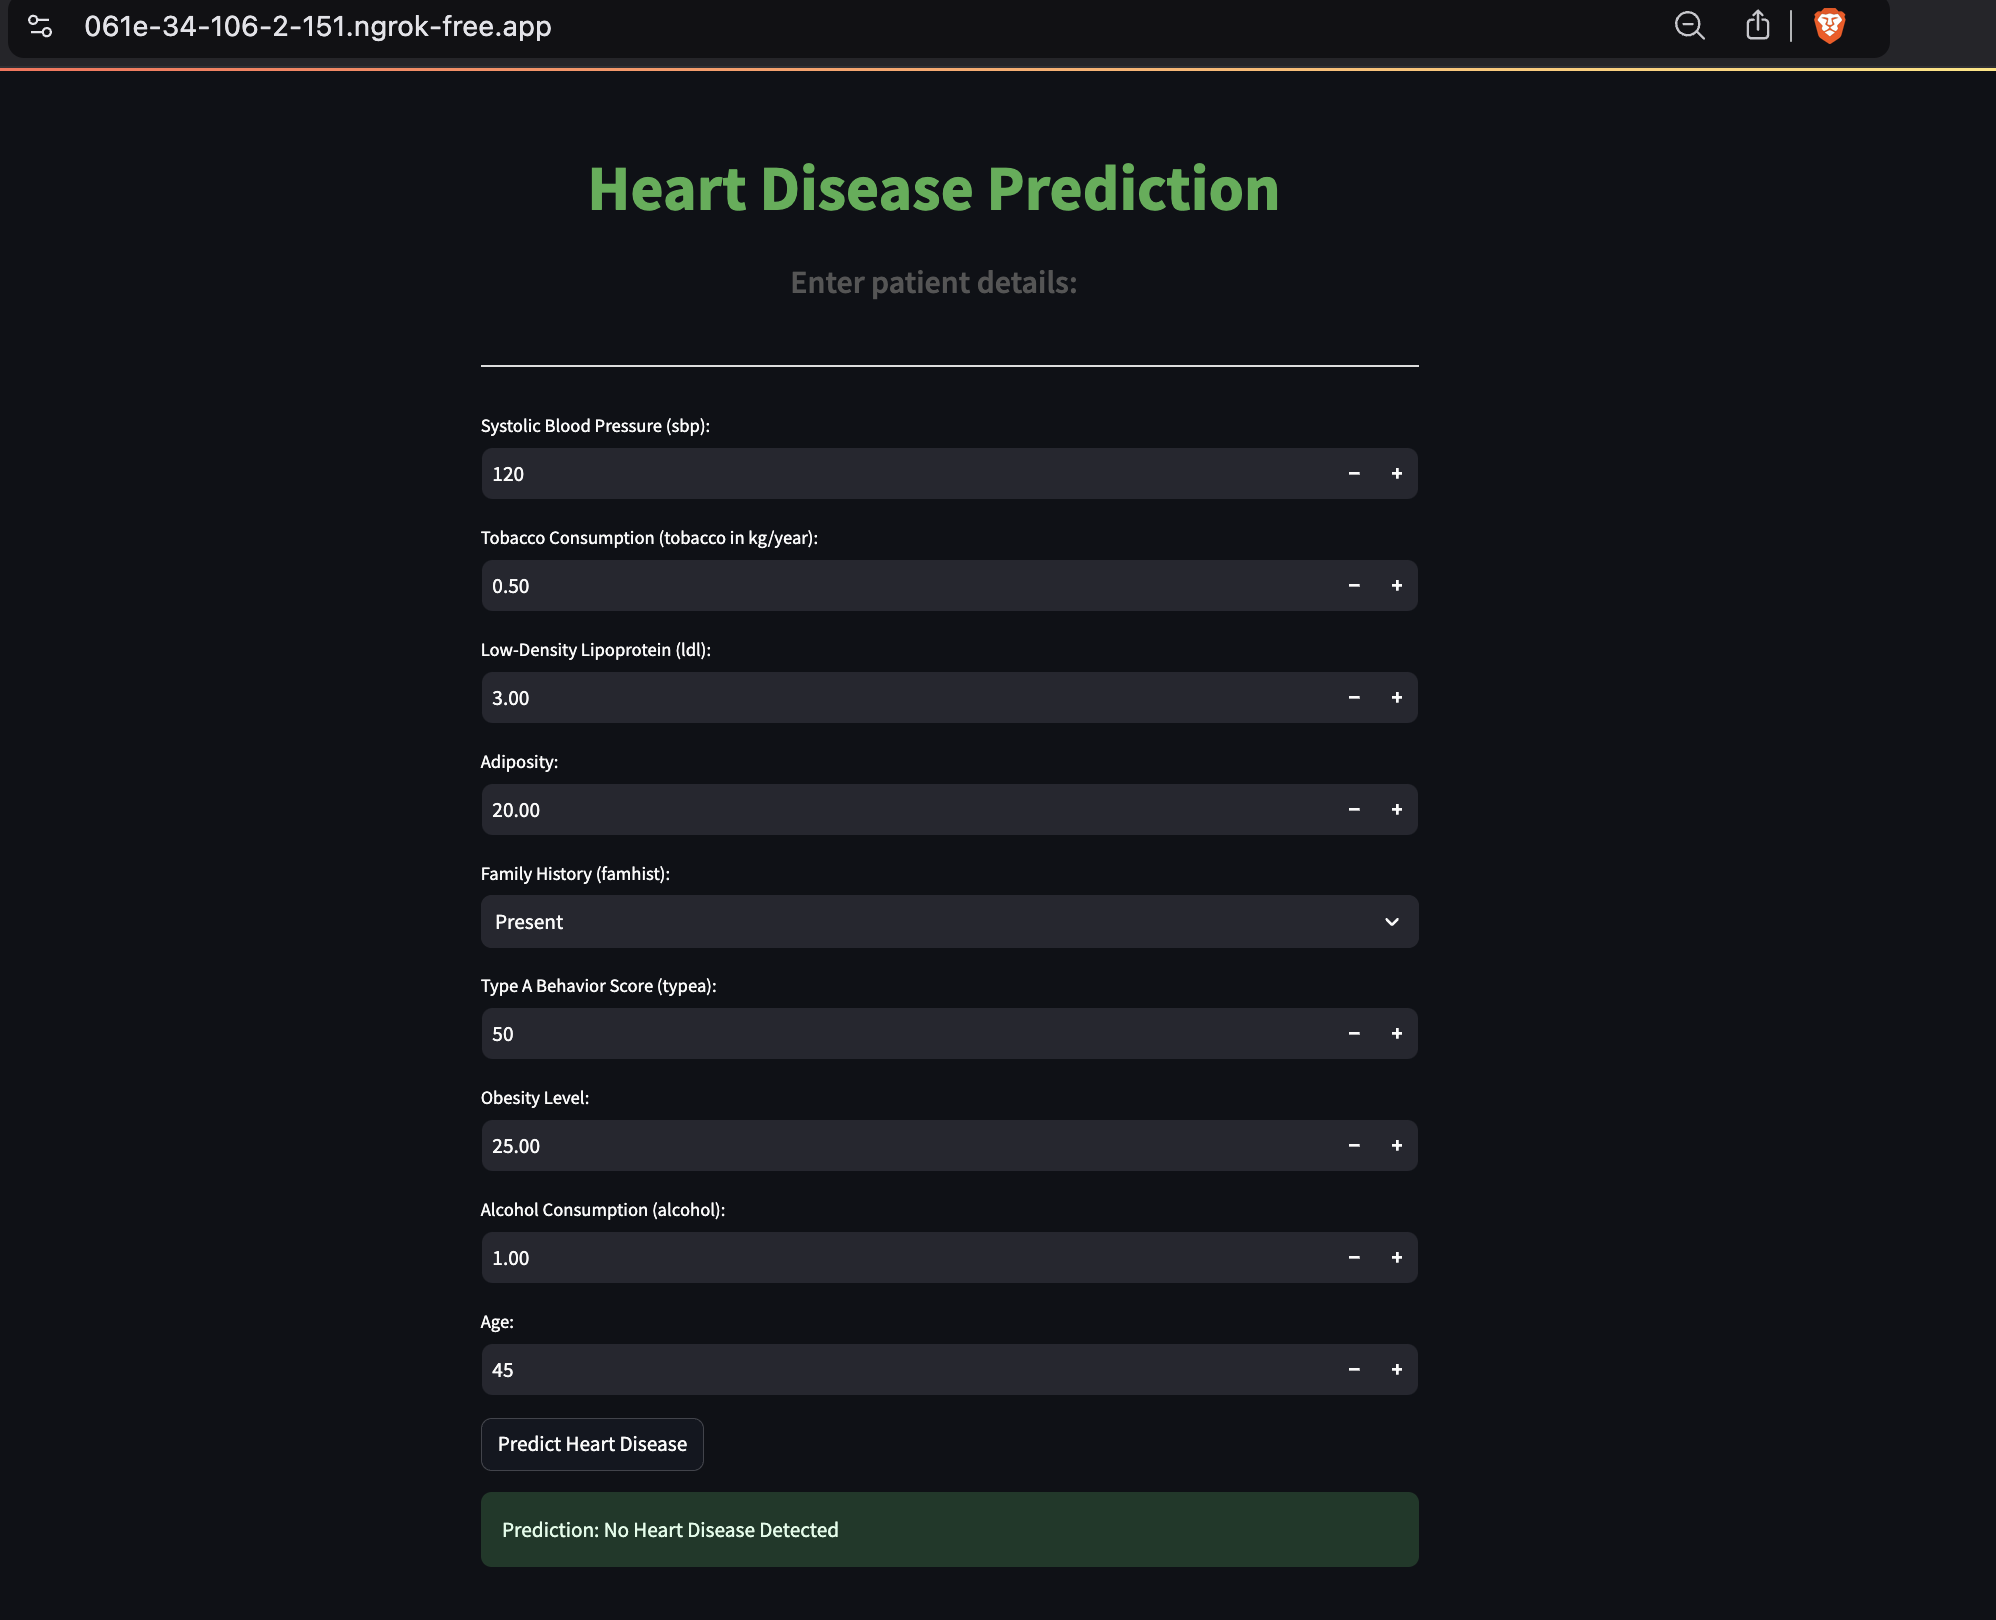

# Alert

In [ ]:
ngrok.kill()